# 04 — Jobs Don't Automate. Tasks Do.

"Will AI replace my job?" is the wrong question.

Every occupation is a *bundle of tasks*. Some tasks within the same job are
90% automated while others are 0% automated. A Word Processor's transcription
tasks are fully automated, but their document design tasks require human judgment.

This within-occupation heterogeneity is why occupation-level prediction fails —
and why the automation frontier is genuinely jagged.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import build_task_feature_matrix, load_onet_skills
from src.features import (
    build_feature_matrix, compute_within_occupation_heterogeneity,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261', 'teal': '#2A9D8F'}

In [2]:
tasks = build_task_feature_matrix()
het = compute_within_occupation_heterogeneity(tasks)
het_reliable = het[het['n_tasks'] >= 5].copy()
print(f'{len(het_reliable)} occupations with >= 5 tasks')

319 occupations with >= 5 tasks


## Case studies: the jagged interior of occupations

Let's look inside specific occupations to see how tasks differ.

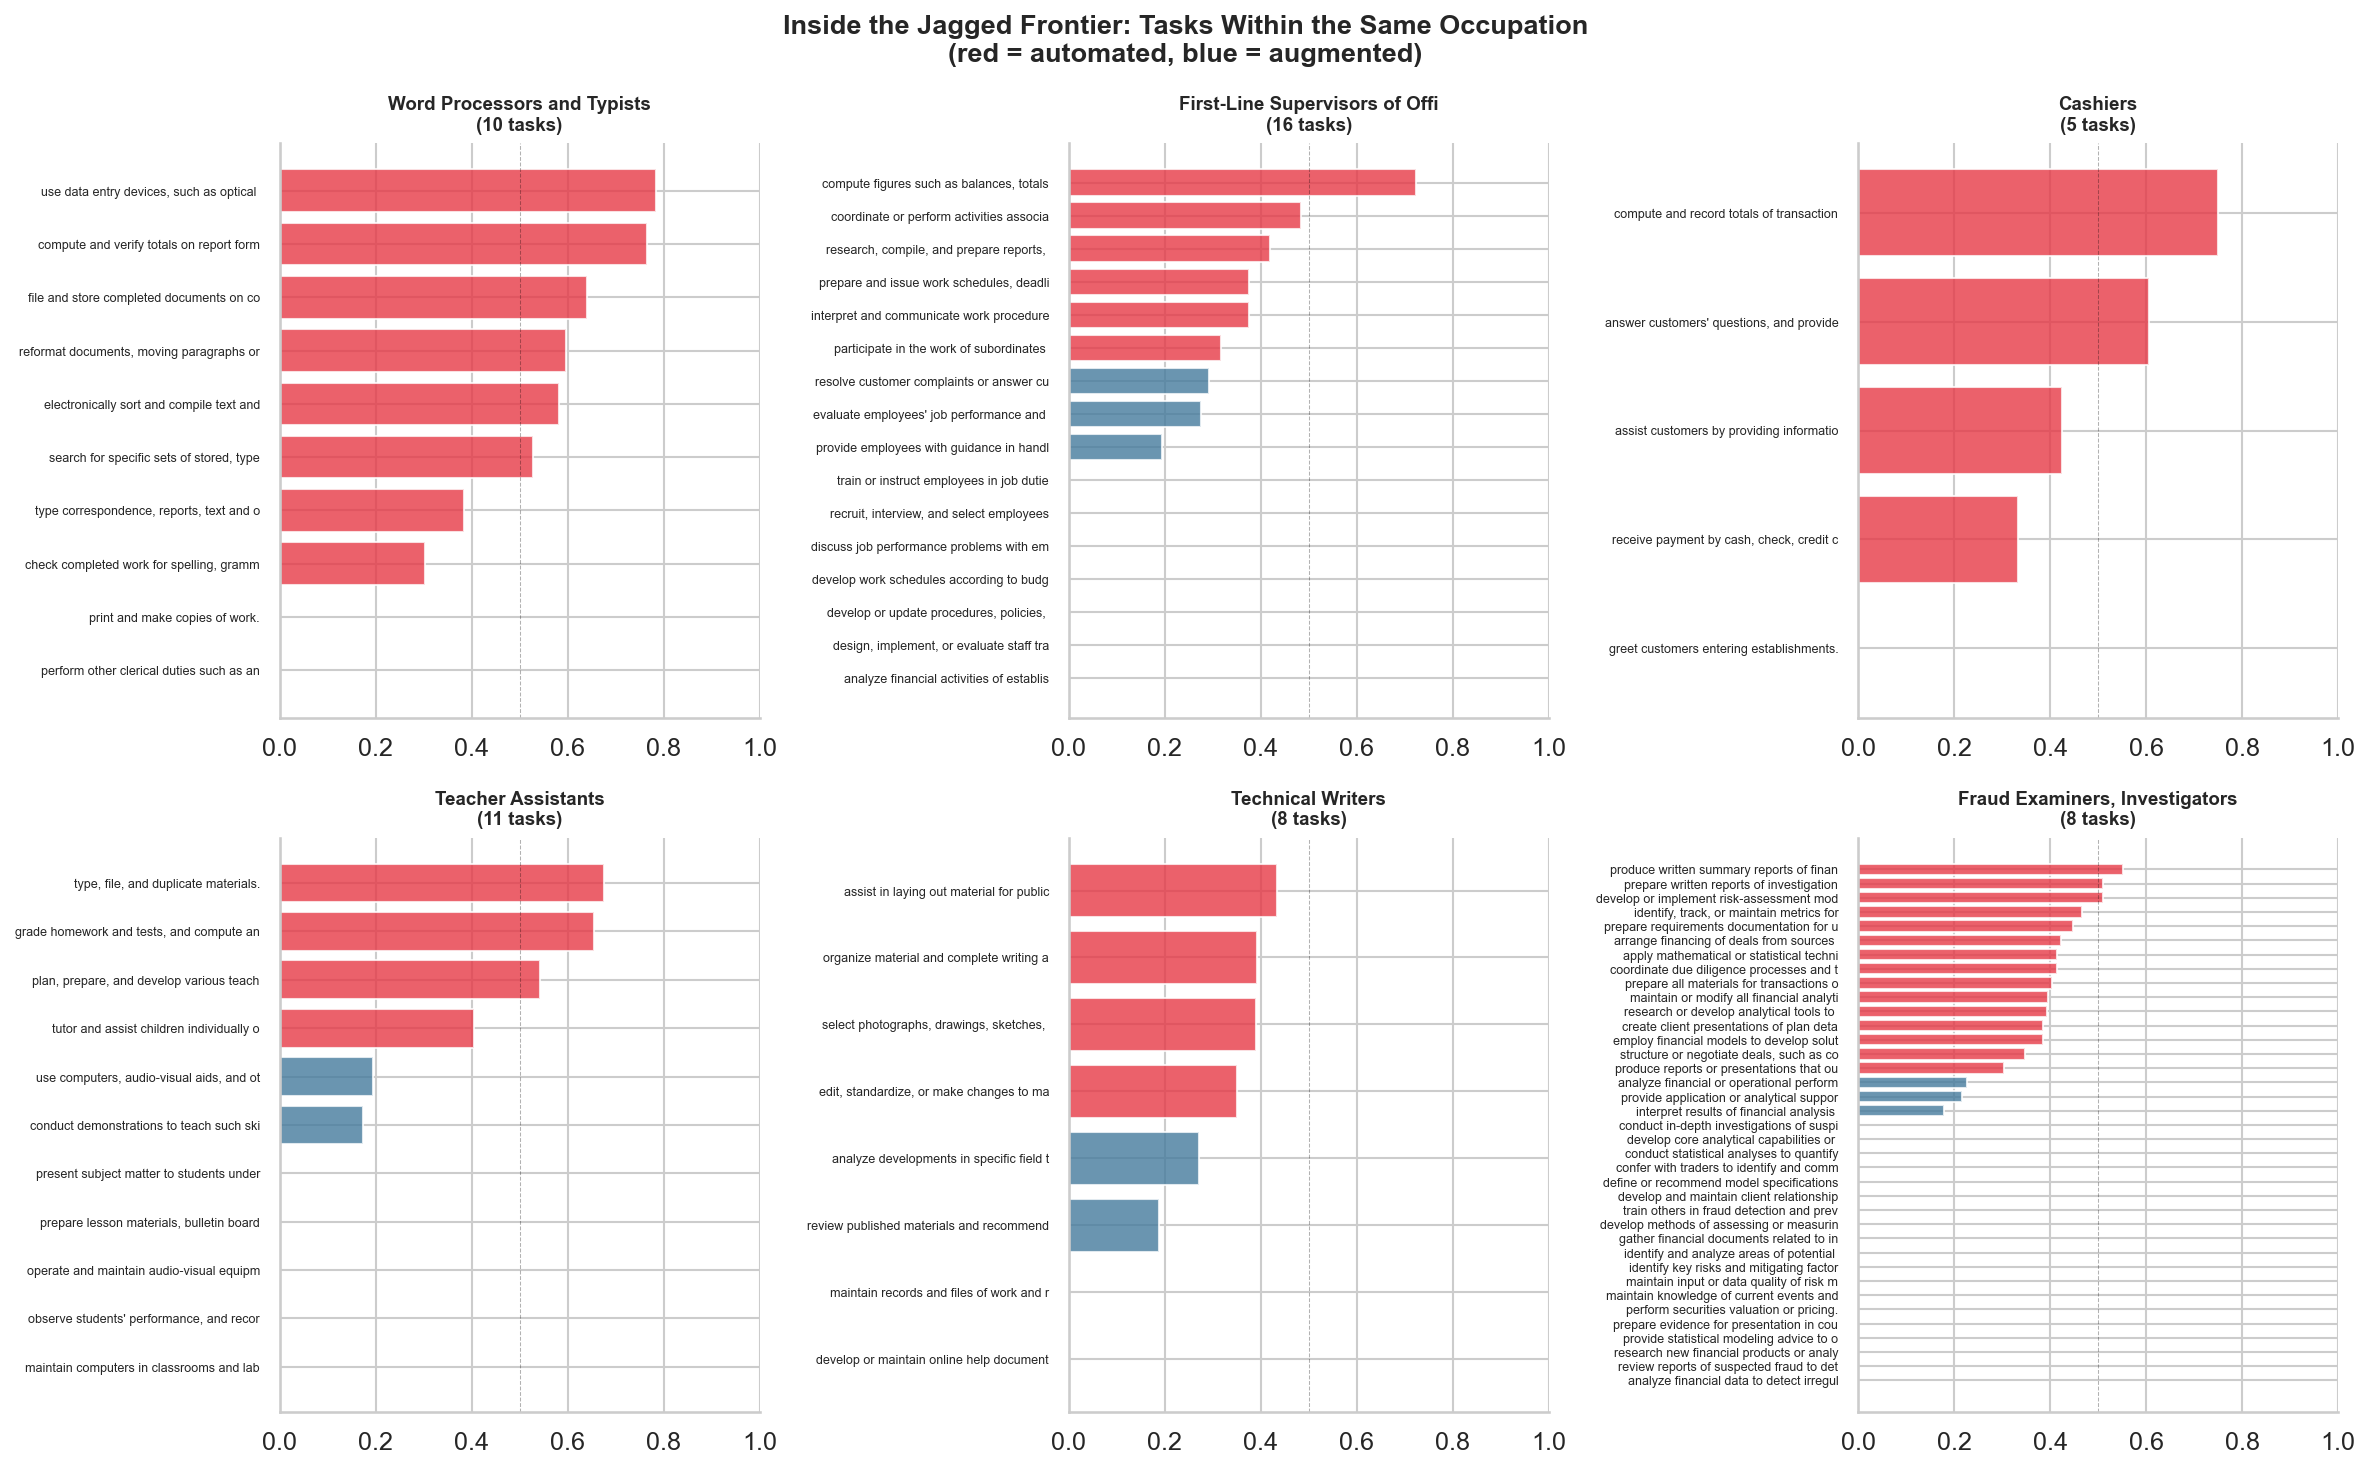

Each panel shows ONE occupation. The tasks within it span from fully automated
to fully augmented. The occupation-level average hides this crucial variation.


In [3]:
# Pick interesting occupations with high heterogeneity
cases = het_reliable.nlargest(6, 'autonomy_range')

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (_, occ) in zip(axes.flat, cases.iterrows()):
    occ_tasks = tasks[tasks['soc_code'] == occ['soc_code']].copy()
    occ_tasks = occ_tasks.sort_values('automation_share', ascending=True)
    
    # Truncate task names
    labels = occ_tasks['task_name'].str[:40].values
    auto = occ_tasks['automation_share'].values
    
    colors = [C['auto'] if a > 0.3 else C['aug'] for a in auto]
    ax.barh(range(len(auto)), auto, color=colors, alpha=0.8)
    ax.set_yticks(range(len(auto)))
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlim(0, 1)
    title = occ['title'] if pd.notna(occ['title']) else occ['soc_code']
    ax.set_title(f"{title[:30]}\n({occ['n_tasks']:.0f} tasks)", fontsize=9, fontweight='bold')
    ax.axvline(0.5, color='black', linestyle='--', linewidth=0.5, alpha=0.3)

plt.suptitle('Inside the Jagged Frontier: Tasks Within the Same Occupation\n'
             '(red = automated, blue = augmented)',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/10_jagged_interior.png', bbox_inches='tight')
plt.show()

print('Each panel shows ONE occupation. The tasks within it span from fully automated')
print('to fully augmented. The occupation-level average hides this crucial variation.')

## The jagged frontier: wage explains almost nothing

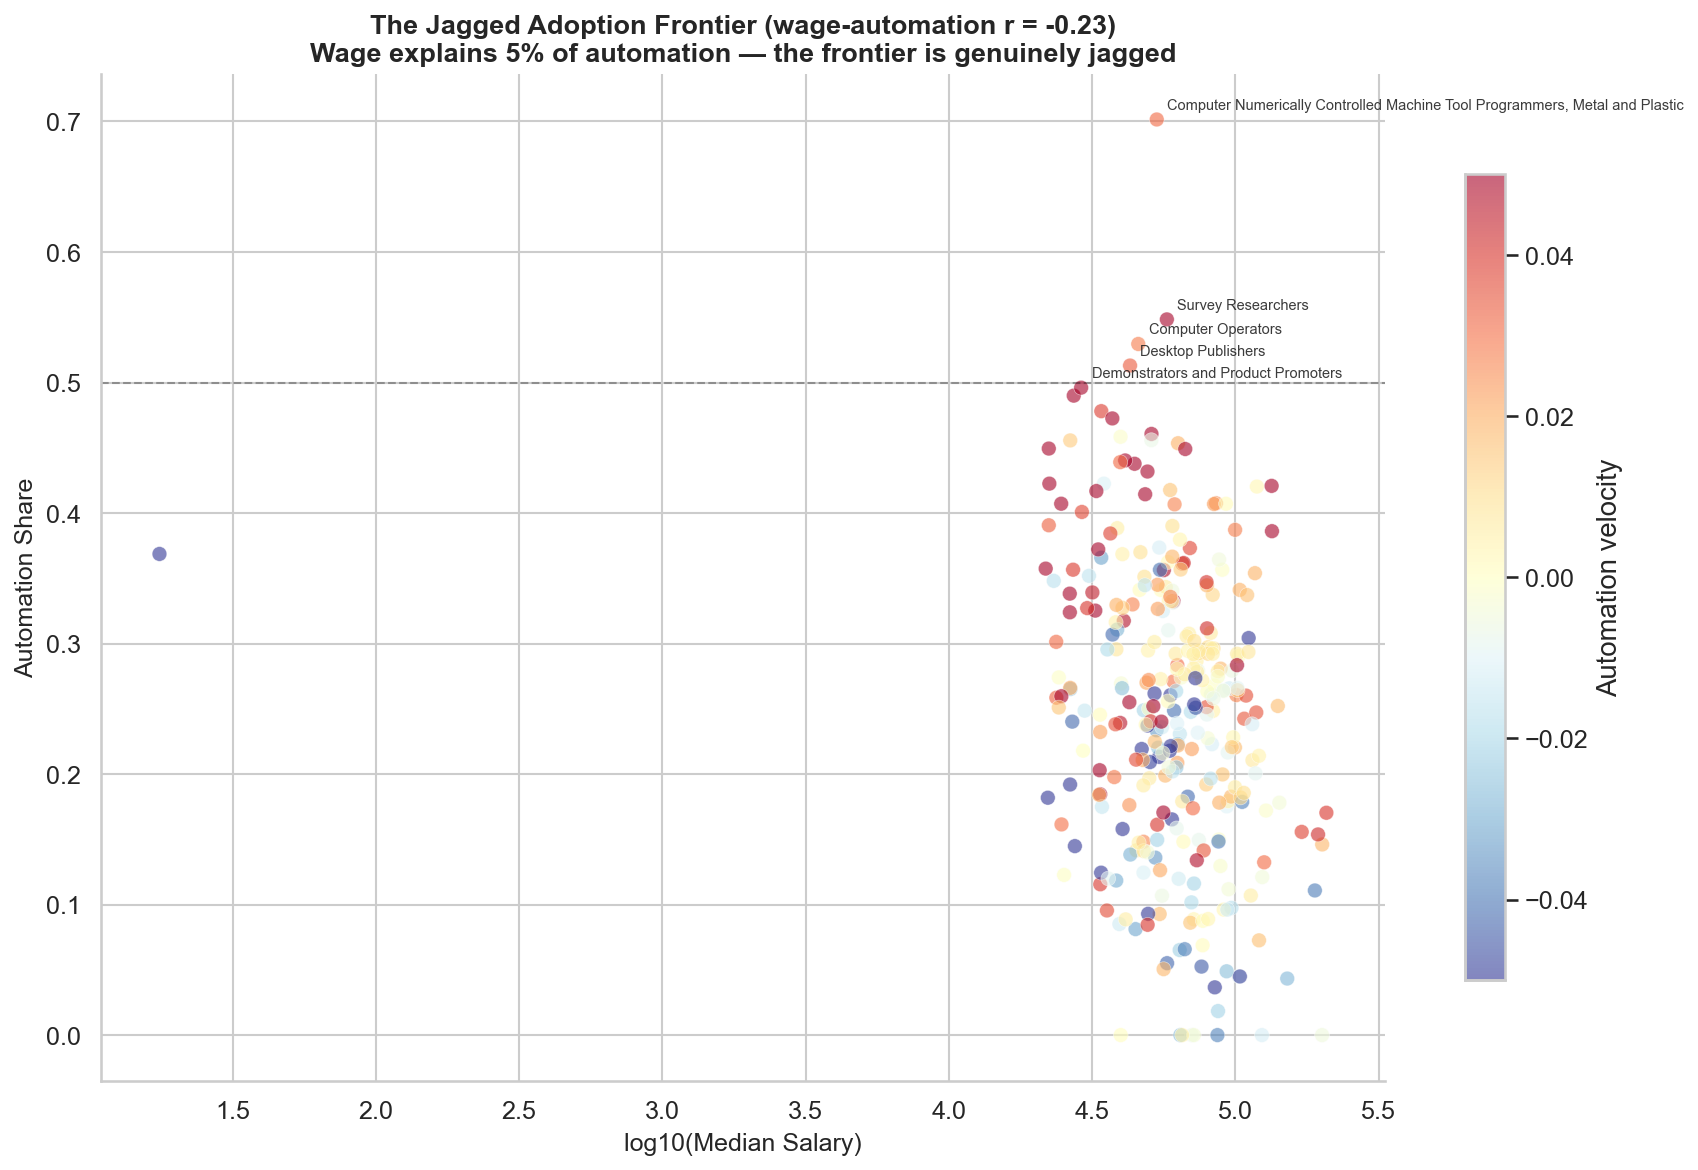

In [4]:
occ_features = build_feature_matrix()
plot_df = occ_features.dropna(subset=['mediansalary', 'latest_automation_share']).copy()
plot_df['log_salary'] = np.log10(plot_df['mediansalary'].clip(lower=1))
corr = plot_df['log_salary'].corr(plot_df['latest_automation_share'])

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    plot_df['log_salary'], plot_df['latest_automation_share'],
    c=plot_df.get('automation_velocity', 0).fillna(0),
    cmap='RdYlBu_r', s=50, alpha=0.6, edgecolors='white', linewidth=0.3,
    vmin=-0.05, vmax=0.05,
)
plt.colorbar(scatter, ax=ax, label='Automation velocity', shrink=0.8)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.3)

highlights = plot_df.nlargest(5, 'latest_automation_share')
for _, row in highlights.iterrows():
    ax.annotate(row['title'], (row['log_salary'], row['latest_automation_share']),
                fontsize=7, alpha=0.9, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('log10(Median Salary)', fontsize=12)
ax.set_ylabel('Automation Share', fontsize=12)
ax.set_title(f'The Jagged Adoption Frontier (wage-automation r = {corr:.2f})\n'
             f'Wage explains {corr**2:.0%} of automation — the frontier is genuinely jagged',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/11_jagged_frontier.png', bbox_inches='tight')
plt.show()

## What skills DO predict automation resistance?

O*NET rates occupations on 35 skills. Some of these predict automation
far better than wage does.

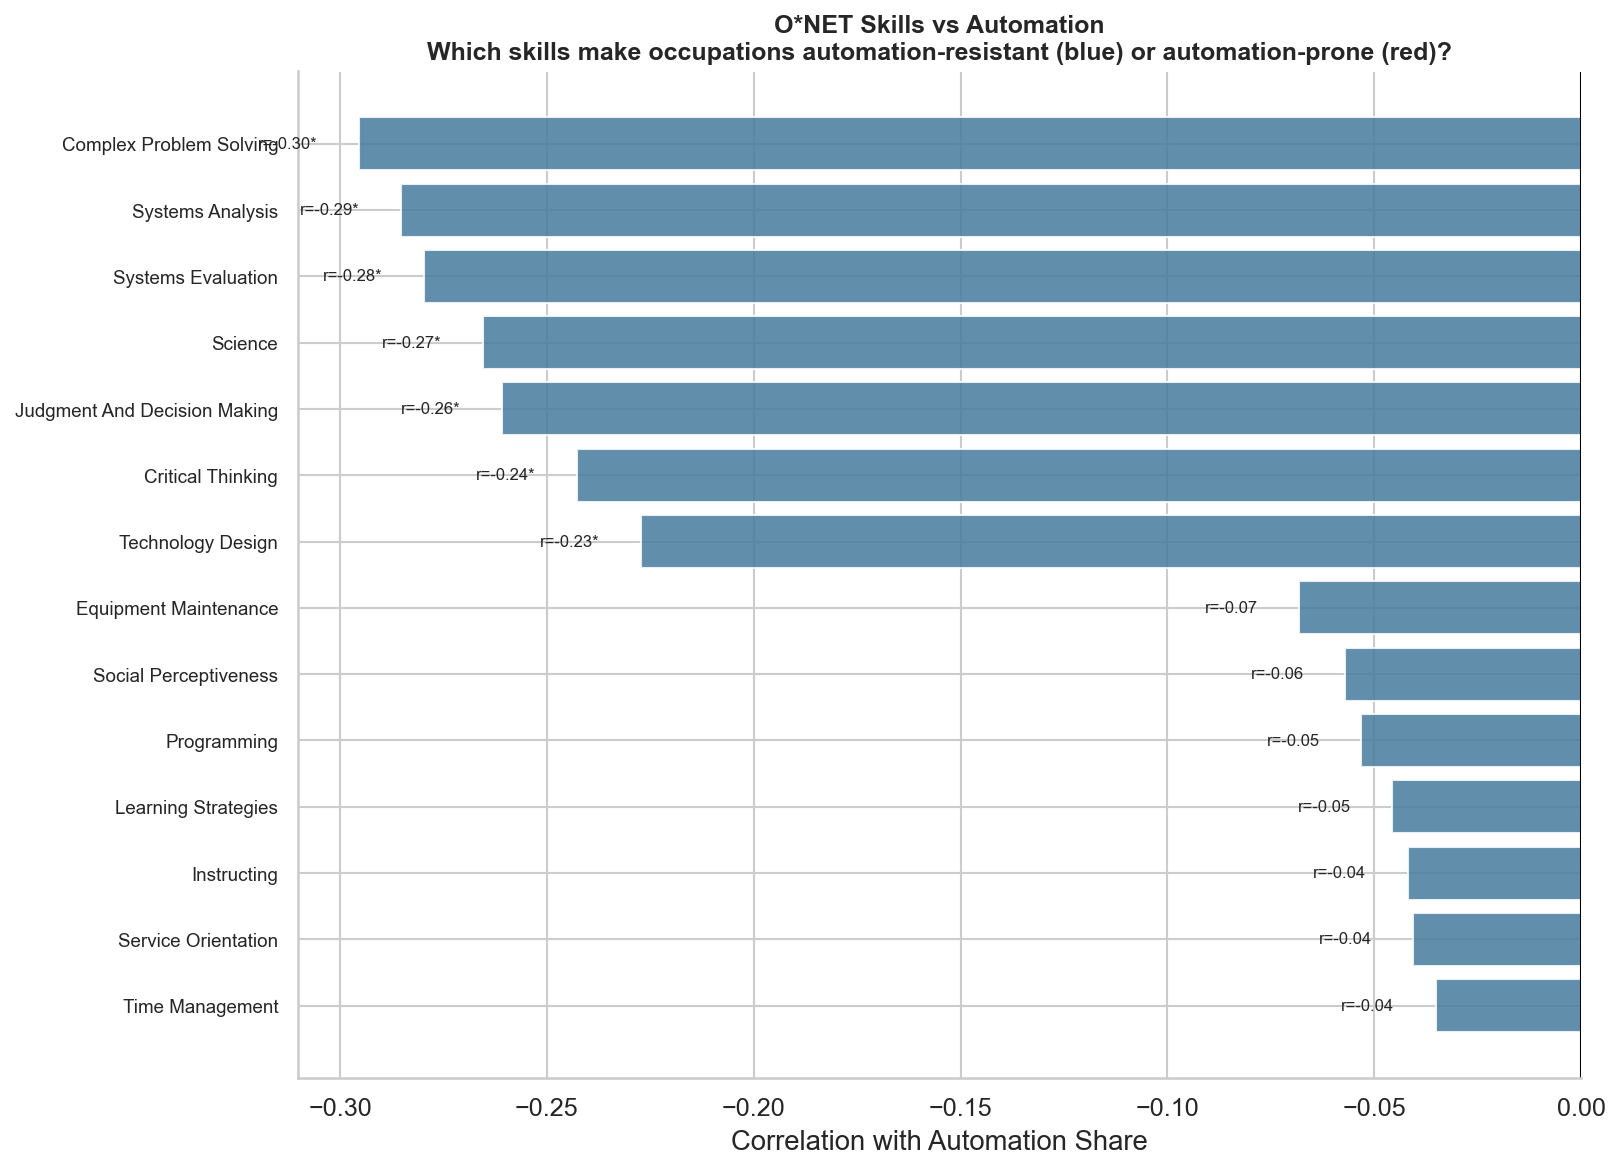

Skills associated with automation RESISTANCE:
  Complex Problem Solving                  r=-0.295
  Systems Analysis                         r=-0.285
  Systems Evaluation                       r=-0.280
  Science                                  r=-0.266
  Judgment And Decision Making             r=-0.261

Skills associated with automation ADOPTION:
  Programming                              r=-0.053
  Learning Strategies                      r=-0.046
  Instructing                              r=-0.042
  Service Orientation                      r=-0.041
  Time Management                          r=-0.035


In [5]:
skills = load_onet_skills()
skill_cols = [c for c in skills.columns if c.startswith('skill_')]

occ_skills = occ_features[['soc_code', 'latest_automation_share']].merge(
    skills, on='soc_code', how='inner'
)

corrs = []
for col in skill_cols:
    valid = occ_skills[['latest_automation_share', col]].dropna()
    if len(valid) > 30:
        r, p = stats.pearsonr(valid['latest_automation_share'], valid[col])
        corrs.append((col.replace('skill_', '').replace('_', ' ').title(), r, p))

corrs.sort(key=lambda x: x[1])

# Show top and bottom
fig, ax = plt.subplots(figsize=(11, 8))
top_bottom = corrs[:7] + corrs[-7:]
names = [c[0] for c in top_bottom]
vals = [c[1] for c in top_bottom]
colors_list = [C['auto'] if v > 0 else C['aug'] for v in vals]

ax.barh(range(len(names)), vals, color=colors_list, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.axvline(0, color='black', linewidth=1)
ax.invert_yaxis()
ax.set_xlabel('Correlation with Automation Share')
ax.set_title('O*NET Skills vs Automation\n'
             'Which skills make occupations automation-resistant (blue) or automation-prone (red)?',
             fontsize=12, fontweight='bold')

for i, (name, r, p) in enumerate(top_bottom):
    sig = '*' if p < 0.05 else ''
    ax.text(r + (0.01 if r > 0 else -0.01), i, f'r={r:+.2f}{sig}',
            va='center', fontsize=8, ha='left' if r > 0 else 'right')

sns.despine()
plt.tight_layout()
plt.savefig('../figures/12_skills_vs_automation.png', bbox_inches='tight')
plt.show()

print('Skills associated with automation RESISTANCE:')
for name, r, p in corrs[:5]:
    print(f'  {name:40s} r={r:+.3f}')
print()
print('Skills associated with automation ADOPTION:')
for name, r, p in corrs[-5:]:
    print(f'  {name:40s} r={r:+.3f}')

---

**Key findings:**
1. **Jobs don't automate — tasks do.** Within the same occupation, task automation ranges from 0% to 90%+
2. **Wage explains almost nothing** about automation — the frontier is genuinely jagged
3. **Specific skills predict resistance**: social perceptiveness, persuasion, service orientation resist automation; equipment-related skills correlate with it
4. **The occupation-level null result is itself the finding** — prediction fails *because* task heterogeneity within occupations is high

**Next:** [05_synthesis.ipynb](05_synthesis.ipynb)